# IndoBERTweet Fine-Tuning — Toxic Model (Full Dataset Optuna)
**Platform:** Kaggle (GPU T4)

**Strategy:** Single-task model for **toxic detection**. Optuna runs K=3 StratifiedKFold on the **full 80% training set**. 30 trials for a more thorough hyperparameter search.

**Output:** `indobertweet_toxic_full_finetuned/`

In [4]:
# Check that GPU has been enabled before running code
import torch
print(torch.cuda.is_available())       # should print True
print(torch.cuda.get_device_name(0))   # should print Tesla T4

True
Tesla T4


## 1. Install & Imports

In [5]:
!pip install optuna transformers datasets scikit-learn emoji --quiet

import re
import emoji
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import optuna

from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score,
    precision_score, recall_score,
    average_precision_score
)
from datasets import load_dataset

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN    = 128
SEED       = 42

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"SEED: {SEED}")


Device: cuda
GPU: Tesla T4
SEED: 42


## 2. Kaggle Dataset Path


In [6]:
MODEL_NAME = "/kaggle/input/datasets/jinjiecheow/indobertweet/indobertweet-base-uncased"

import os
print("IndoBERTweet files:", os.listdir(MODEL_NAME))


IndoBERTweet files: ['config.json', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors']


## 3. Preprocessing & Data Loading
Task-specific balancing for **toxic detection only** (1:3 ratio, no union with polar task).

In [7]:
# Susanto et. al. (2025) did not mention the text preprocessing steps they employed.
# Hence, the code below follows Koto et. al. (2021) for baseline text preprocessing,
# with extensions to address the structural characteristics of YouTube comments.
# The same preprocessing pipeline is used for both fine-tuning and inference.

def preprocess(text):
    text = str(text).lower()                                                    # IndoBERTweet is an uncased model
    text = re.sub(r'http\S+|www\.\S+', 'HTTPURL', text)                         # URL → learned token
    text = re.sub(r'@\w+', '@USER', text)                                       # mention → learned token
    text = emoji.demojize(text, delimiters=(" ", " "))                          # emoji → text
    text = text.replace("<br>", " ").replace("\n", " ").replace("\t", " ")      # remove formatting artifacts
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                                  # squash spam
    text = re.sub(r'\s+', ' ', text)                                            # replace all whitespace sequences
    return text.strip()


def majority_vote(label_list):
    if not label_list:
        return 0
    label_list = [int(x) for x in label_list]
    return int(sum(label_list) > len(label_list) / 2)


def balance_toxic(texts, labels, ratio=3):
    """
    Balance toxic task at 1:ratio.
    Single task only — no union. Dict deduplication for determinism.
    """
    rng        = np.random.default_rng(SEED)
    combined   = list(zip(texts, labels))
    pos        = [x for x in combined if x[1] == 1]
    neg        = [x for x in combined if x[1] == 0]
    neg_sample = [neg[i] for i in rng.choice(
        len(neg), min(len(neg), len(pos) * ratio), replace=False)]
    balanced   = list({tuple(x): x for x in pos + neg_sample}.values())
    rng.shuffle(balanced)
    t, l = zip(*balanced)
    return list(t), list(l)


print('Loading IndoDiscourse from HuggingFace...')
ds = load_dataset('Exqrch/IndoDiscourse', 'main', split='main')
texts, labels = [], []
for row in ds:
    texts.append(row['text'])
    labels.append(majority_vote(row['toxicity']))
print(f'Loaded {len(texts):,} texts')

texts, labels = balance_toxic(texts, labels)
print(f'Balanced dataset: {len(texts):,} samples')
print(f'Toxic positive: {sum(labels):,} ({sum(labels)/len(labels)*100:.1f}%)')

tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED
)
print(f'Train (80%): {len(tr_texts):,} | Test (20%): {len(te_texts):,}')


print('\u2713 Full training set will be used for Optuna trials')
print(f'  Optuna will run on {len(tr_texts):,} training texts')

Loading IndoDiscourse from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

indotoxic2024_annotated_data_v2_final.js(…):   0%|          | 0.00/21.6M [00:00<?, ?B/s]

Generating main split:   0%|          | 0/28448 [00:00<?, ? examples/s]

Loaded 28,448 texts
Balanced dataset: 8,414 samples
Toxic positive: 2,068 (24.6%)
Train (80%): 6,731 | Test (20%): 1,683
✓ Full training set will be used for Optuna trials
  Optuna will run on 6,731 training texts


## 4. Dataset Class & Model
Single-task `IndoBERTweetSingle` with one classification head for **toxic detection**.

In [8]:
class SingleTaskDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts, self.labels, self.tokenizer = texts, labels, tokenizer

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            preprocess(self.texts[idx]),
            max_length=MAX_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'toxic':   torch.tensor(self.labels[idx], dtype=torch.float),
        }


class IndoBERTweetSingle(nn.Module):
    """Single-task model for toxic detection."""
    def __init__(self, dropout=0.1):
        super().__init__()
        self.bert      = BertModel.from_pretrained(MODEL_NAME)
        self.drop      = nn.Dropout(dropout)
        self.task_head = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.drop(out.pooler_output)
        return self.task_head(pooled).squeeze(-1)


tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('\u2713 Ready')


✓ Ready


## 5. Optuna Objective Function
Each trial runs **K=3 StratifiedKFold on the full 80% training set** (~8,600 texts). 30 trials for thorough hyperparameter search.  

Objective: **Toxic Macro F1**

In [9]:
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

K = 3

def objective(trial):
    lr           = trial.suggest_float('lr',           1e-5, 1e-4, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [8, 16, 32])
    dropout      = trial.suggest_float('dropout',      0.1, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-1, log=True)
    warmup_steps = trial.suggest_int('warmup_steps',   0, 500, step=100)

    skf      = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
    fold_f1s = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(tr_texts, tr_labels)):
        fold_tr_t = [tr_texts[i]  for i in train_idx]
        fold_tr_l = [tr_labels[i] for i in train_idx]
        fold_va_t = [tr_texts[i]  for i in val_idx]
        fold_va_l = [tr_labels[i] for i in val_idx]

        train_dl = DataLoader(
            SingleTaskDataset(fold_tr_t, fold_tr_l, tokenizer),
            batch_size=batch_size, shuffle=True)
        val_dl = DataLoader(
            SingleTaskDataset(fold_va_t, fold_va_l, tokenizer),
            batch_size=batch_size)

        model     = IndoBERTweetSingle(dropout=dropout).to(DEVICE)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, warmup_steps, len(train_dl) * 2)
        criterion = nn.BCEWithLogitsLoss()

        for _ in range(2):
            model.train()
            for batch in train_dl:
                optimizer.zero_grad()
                logit = model(batch['input_ids'].to(DEVICE),
                              batch['attention_mask'].to(DEVICE))
                loss  = criterion(logit, batch['toxic'].to(DEVICE))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in val_dl:
                logit = model(batch['input_ids'].to(DEVICE),
                              batch['attention_mask'].to(DEVICE))
                preds.extend((torch.sigmoid(logit) > 0.5).cpu().numpy())
                trues.extend(batch['toxic'].numpy())

        fold_f1 = f1_score(trues, preds, average='macro')
        fold_f1s.append(fold_f1)

        trial.report(np.mean(fold_f1s), fold)
        if trial.should_prune():
            del model
            torch.cuda.empty_cache()
            raise optuna.TrialPruned()

        del model
        torch.cuda.empty_cache()

    return np.mean(fold_f1s)


print('\u2713 Objective function defined (StratifiedKFold K=3, full dataset, toxic F1)')


✓ Objective function defined (StratifiedKFold K=3, full dataset, toxic F1)


## 6. Run Optuna Study
30 trials × K=3 folds on full training set. Maximises **Toxic Macro F1**.

In [10]:
optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = TPESampler(seed=SEED)
pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=1)
study   = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('\n' + '='*55)
print('OPTUNA RESULTS — TOXIC MODEL')
print('='*55)
print(f'Toxic F1  : {study.best_value:.4f}')
print(f'Best trial   : {study.best_trial.number}')
print(f'Completed    : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])} trials')
print(f'Pruned       : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])} trials')
print('\nBest params  :')
for k, v in study.best_params.items():
    print(f'  {k:<15}: {v}')


[I 2026-07-18 19:59:44,634] A new study created in memory with name: no-name-ee3b2000-b478-4312-8879-204ae38226e7


  0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[I 2026-07-19 00:40:10,157] Trial 28 pruned. 


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[I 2026-07-19 00:51:06,757] Trial 29 finished with value: 0.7705948498380994 and parameters: {'lr': 3.242768542284611e-05, 'batch_size': 16, 'dropout': 0.16547758877514537, 'weight_decay': 0.0003415775513931372, 'warmup_steps': 0}. Best is trial 0 with value: 0.7728764451324873.

OPTUNA RESULTS — TOXIC MODEL
Toxic F1  : 0.7729
Best trial   : 0
Completed    : 17 trials
Pruned       : 13 trials

Best params  :
  lr             : 2.368863950364079e-05
  batch_size     : 8
  dropout        : 0.1624074561769746
  weight_decay   : 0.00029375384576328325
  warmup_steps   : 0


## 7. Visualise Optuna Results

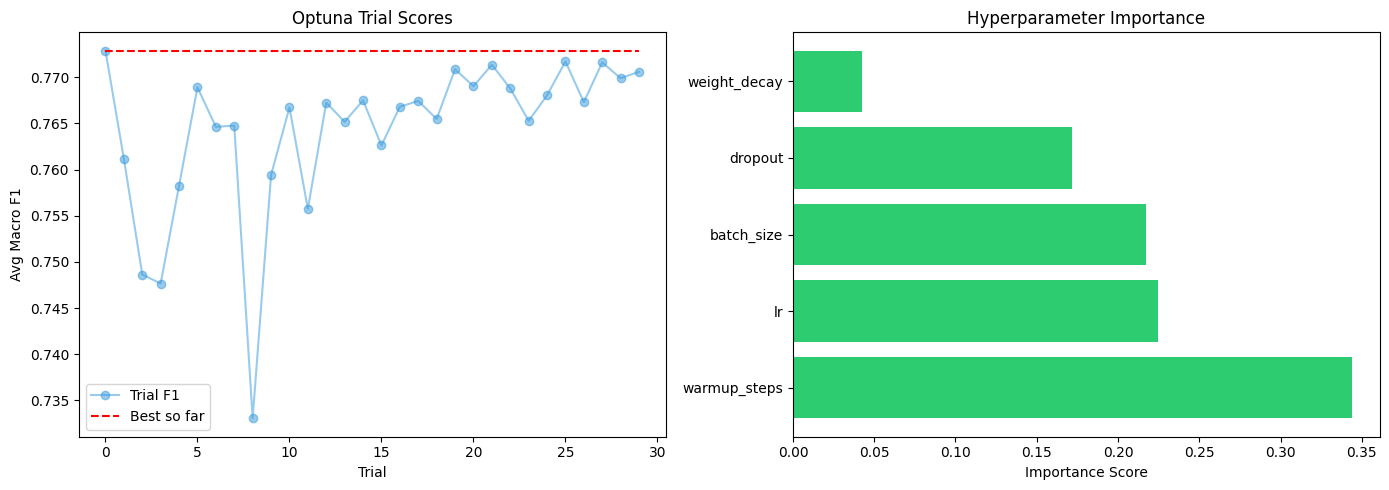

✓ Saved to /kaggle/working/optuna_results.png


In [11]:
import matplotlib.pyplot as plt

# Filter out pruned trials (value = None)
completed = [t for t in study.trials if t.value is not None]
trial_numbers = [t.number for t in completed]
trial_values  = [t.value  for t in completed]
best_so_far   = pd.Series(trial_values).cummax().tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial scores over time
axes[0].plot(trial_numbers, trial_values, "o-",
             alpha=0.5, color="#3498db", label="Trial F1")
axes[0].plot(trial_numbers, best_so_far, "r--", label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Avg Macro F1")
axes[0].set_title("Optuna Trial Scores")
axes[0].legend()

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()),
             list(importances.values()), color="#2ecc71")
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Hyperparameter Importance")

plt.tight_layout()
plt.savefig("/kaggle/working/optuna_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2713 Saved to /kaggle/working/optuna_results.png")

## 8. Final Training with Best Parameters
Trains on **80% training set** using best Optuna params. Single task: **toxic detection only**.

In [12]:
best = study.best_params
print('Training with best params:')
for k, v in best.items():
    print(f'  {k}: {v}')

train_dl = DataLoader(
    SingleTaskDataset(tr_texts, tr_labels, tokenizer),
    batch_size=best['batch_size'], shuffle=True)
val_dl   = DataLoader(
    SingleTaskDataset(te_texts, te_labels, tokenizer),
    batch_size=best['batch_size'])

model     = IndoBERTweetSingle(dropout=best['dropout']).to(DEVICE)
optimizer = AdamW(model.parameters(),
                  lr=best['lr'], weight_decay=best['weight_decay'])
EPOCHS    = 3
scheduler = get_linear_schedule_with_warmup(
    optimizer, best['warmup_steps'], len(train_dl) * EPOCHS)
criterion = nn.BCEWithLogitsLoss()

best_f1, patience, PATIENCE_LIMIT = 0, 0, 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_dl:
        optimizer.zero_grad()
        logit = model(batch['input_ids'].to(DEVICE),
                      batch['attention_mask'].to(DEVICE))
        loss  = criterion(logit, batch['toxic'].to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    model.eval()
    preds, probs, trues = [], [], []
    with torch.no_grad():
        for batch in val_dl:
            logit = model(batch['input_ids'].to(DEVICE),
                          batch['attention_mask'].to(DEVICE))
            probs.extend(torch.sigmoid(logit).cpu().numpy())
            preds.extend((torch.sigmoid(logit) > 0.5).cpu().numpy())
            trues.extend(batch['toxic'].numpy())

    bin_preds = (np.array(probs) > 0.5).astype(int)
    f1 = f1_score(trues, bin_preds, average='macro')

    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_dl):.4f}')
    print(f'  Toxic F1: {f1:.4f} | '
          f'AUC: {roc_auc_score(trues, probs):.4f} | '
          f'Precision: {precision_score(trues, bin_preds, pos_label=1, zero_division=0):.4f} | '
          f'Recall: {recall_score(trues, bin_preds, pos_label=1, zero_division=0):.4f} | '
          f'PR-AUC: {average_precision_score(trues, probs):.4f}')

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), '/kaggle/working/best_model_toxic_full.pt')
        print(f'  \u2713 Best Toxic model saved (F1: {best_f1:.4f}) — full dataset)')
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE_LIMIT:
            print('Early stopping.')
            break

print(f'\nFinal best Toxic Macro F1: {best_f1:.4f}')


Training with best params:
  lr: 2.368863950364079e-05
  batch_size: 8
  dropout: 0.1624074561769746
  weight_decay: 0.00029375384576328325
  warmup_steps: 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/3 | Loss: 0.4132
  Toxic F1: 0.7701 | AUC: 0.8711 | Precision: 0.6037 | Recall: 0.7293 | PR-AUC: 0.6613
  ✓ Best Toxic model saved (F1: 0.7701) — full dataset)
Epoch 2/3 | Loss: 0.3083
  Toxic F1: 0.7496 | AUC: 0.8786 | Precision: 0.6780 | Recall: 0.5489 | PR-AUC: 0.6684
Epoch 3/3 | Loss: 0.2128
  Toxic F1: 0.7630 | AUC: 0.8783 | Precision: 0.6568 | Recall: 0.6140 | PR-AUC: 0.6683

Final best Toxic Macro F1: 0.7701


In [13]:
model.load_state_dict(
    torch.load('/kaggle/working/best_model_toxic_full.pt', map_location=DEVICE)
)
model.eval()
preds, probs, trues = [], [], []
with torch.no_grad():
    for batch in val_dl:
        logit = model(batch['input_ids'].to(DEVICE),
                      batch['attention_mask'].to(DEVICE))
        probs.extend(torch.sigmoid(logit).cpu().numpy())
        trues.extend(batch['toxic'].numpy())

bin_preds = (np.array(probs) > 0.5).astype(int)

metrics_df = pd.DataFrame([{
    'toxic_f1':            f1_score(trues, bin_preds, average='macro'),
    'toxic_auc':           roc_auc_score(trues, probs),
    'toxic_pos_precision': precision_score(trues, bin_preds, pos_label=1, zero_division=0),
    'toxic_pos_recall':    recall_score(trues, bin_preds, pos_label=1, zero_division=0),
    'toxic_pr_auc':        average_precision_score(trues, probs),
}])

metrics_df.to_csv('/kaggle/working/evaluation_metrics_toxic_full.csv', index=False)
print('\u2713 Metrics saved to /kaggle/working/evaluation_metrics_toxic_full.csv')
print(metrics_df.T.rename(columns={0: 'Score'}).to_string())


✓ Metrics saved to /kaggle/working/evaluation_metrics_toxic_full.csv
                        Score
toxic_f1             0.770146
toxic_auc            0.871123
toxic_pos_precision  0.603734
toxic_pos_recall     0.729323
toxic_pr_auc         0.661344


In [14]:
import shutil
shutil.copy('/kaggle/working/best_model_toxic_full.pt',
            '/kaggle/working/best_model_toxic_full_backup.pt')
print('\u2713 best_model_toxic_full.pt backed up')
print(f'  Files: {[f for f in os.listdir("/kaggle/working/") if not f.startswith(".")]}')


✓ best_model_toxic_full.pt backed up
  Files: ['best_model_toxic_full_backup.pt', 'evaluation_metrics_toxic_full.csv', 'best_model_toxic_full.pt', 'optuna_results.png']


## 9. Save Model

In [15]:
import os, zipfile, shutil

SAVE_DIR = '/kaggle/working/indobertweet_toxic_full_finetuned'
os.makedirs(SAVE_DIR, exist_ok=True)

model.load_state_dict(
    torch.load('/kaggle/working/best_model_toxic_full.pt', map_location=DEVICE)
)

model.bert.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
torch.save({'toxic_head': model.task_head.state_dict()},
           os.path.join(SAVE_DIR, 'classification_head.pt'))
pd.DataFrame([study.best_params]).to_csv(
    os.path.join(SAVE_DIR, 'best_params.csv'), index=False)

for fname in os.listdir(SAVE_DIR):
    shutil.copy2(os.path.join(SAVE_DIR, fname),
                 f'/kaggle/working/{fname}')
    print(f'  \u2713 {fname} saved to root level')

ZIP_PATH = '/kaggle/working/indobertweet_toxic_full_finetuned.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(SAVE_DIR):
        zf.write(os.path.join(SAVE_DIR, fname), fname)

print(f'\n\u2713 Zip: {ZIP_PATH}')
print(f'  Contents: {zipfile.ZipFile(ZIP_PATH).namelist()}')
print(f'  Size: {os.path.getsize(ZIP_PATH)/1e6:.1f} MB')
print([f for f in os.listdir('/kaggle/working/') if not f.startswith('.')])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ config.json saved to root level
  ✓ tokenizer.json saved to root level
  ✓ classification_head.pt saved to root level
  ✓ model.safetensors saved to root level
  ✓ tokenizer_config.json saved to root level
  ✓ best_params.csv saved to root level

✓ Zip: /kaggle/working/indobertweet_toxic_full_finetuned.zip
  Contents: ['config.json', 'tokenizer.json', 'classification_head.pt', 'model.safetensors', 'tokenizer_config.json', 'best_params.csv']
  Size: 410.4 MB
['best_model_toxic_full_backup.pt', 'config.json', 'indobertweet_toxic_full_finetuned.zip', 'tokenizer.json', 'evaluation_metrics_toxic_full.csv', 'best_model_toxic_full.pt', 'classification_head.pt', 'model.safetensors', 'optuna_results.png', 'tokenizer_config.json', 'best_params.csv', 'indobertweet_toxic_full_finetuned']
